In [1]:
import pandas as pd
df=pd.read_csv("dataset/metrics_data_latest.csv")
df.shape


(1078753, 3)

In [2]:
# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nUnique metrics:")
print(df['metric'].unique())

print("\nMetrics count:")
print(df['metric'].value_counts())

Dataset shape: (1078753, 3)

First few rows:
                 timestamp                 metric       value
0  2026-03-22 21:58:34.851  jvm_memory_used_bytes  12582912.0
1  2026-03-22 21:58:49.851  jvm_memory_used_bytes  14680064.0
2  2026-03-22 21:59:04.851  jvm_memory_used_bytes  14680064.0
3  2026-03-22 21:59:19.851  jvm_memory_used_bytes  14680064.0
4  2026-03-22 21:59:34.851  jvm_memory_used_bytes  16777216.0

Data types:
timestamp        str
metric           str
value        float64
dtype: object

Unique metrics:
<StringArray>
[                       'jvm_memory_used_bytes',
                             'system_cpu_usage',
                     'jvm_threads_live_threads',
 'rate(http_server_requests_seconds_count[1m])']
Length: 4, dtype: str

Metrics count:
metric
jvm_memory_used_bytes                           279162
rate(http_server_requests_seconds_count[1m])    267377
system_cpu_usage                                266107
jvm_threads_live_threads                        266107
N

In [3]:
# Sample data from each metric
metrics_list = df['metric'].unique()
sampled_data = []

for metric in metrics_list:
    metric_data = df[df['metric'] == metric]
    # Sample: first, middle, and last rows
    sample_indices = [0, len(metric_data) // 2, len(metric_data) - 1]
    sampled_data.append(metric_data.iloc[sample_indices])

df_sampled = pd.concat(sampled_data, ignore_index=True)
print(df_sampled)

                  timestamp                                        metric  \
0   2026-03-22 21:58:34.851                         jvm_memory_used_bytes   
1   2026-04-11 07:10:49.851                         jvm_memory_used_bytes   
2   2026-05-03 16:45:13.966                         jvm_memory_used_bytes   
3   2026-03-22 21:58:34.851                              system_cpu_usage   
4   2026-04-12 10:22:34.851                              system_cpu_usage   
5   2026-05-03 16:45:13.966                              system_cpu_usage   
6   2026-03-22 21:58:34.851                      jvm_threads_live_threads   
7   2026-04-12 10:22:34.851                      jvm_threads_live_threads   
8   2026-05-03 16:45:13.966                      jvm_threads_live_threads   
9   2026-05-01 17:08:46.092  rate(http_server_requests_seconds_count[1m])   
10  2026-04-12 07:43:49.851  rate(http_server_requests_seconds_count[1m])   
11  2026-05-03 16:45:13.966  rate(http_server_requests_seconds_count[1m])   

In [4]:
# Display summary statistics for the dataset
print("Dataset Summary Statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nMetric value ranges:")
for metric in metrics_list:
    metric_data = df[df['metric'] == metric]
    print(f"\n{metric}:")
    print(f"  Min: {metric_data['value'].min():.2e}")
    print(f"  Max: {metric_data['value'].max():.2e}")
    print(f"  Mean: {metric_data['value'].mean():.2e}")
    print(f"  Std Dev: {metric_data['value'].std():.2e}")

Dataset Summary Statistics:
              value
count  1.078753e+06
mean   2.337366e+07
std    6.718255e+07
min    0.000000e+00
25%    1.721959e-02
50%    4.424844e-02
75%    3.109330e+01
max    3.308084e+09

Missing values:
timestamp    0
metric       0
value        0
dtype: int64

Metric value ranges:

jvm_memory_used_bytes:
  Min: 0.00e+00
  Max: 3.31e+09
  Mean: 9.03e+07
  Std Dev: 1.07e+08

system_cpu_usage:
  Min: 0.00e+00
  Max: 4.31e-01
  Mean: 1.63e-02
  Std Dev: 1.67e-02

jvm_threads_live_threads:
  Min: 1.00e+00
  Max: 1.14e+02
  Mean: 2.40e+01
  Std Dev: 7.75e+00

rate(http_server_requests_seconds_count[1m]):
  Min: 0.00e+00
  Max: 1.53e-01
  Mean: 2.82e-02
  Std Dev: 1.40e-02


In [5]:
df.head

<bound method NDFrame.head of                        timestamp  \
0        2026-03-22 21:58:34.851   
1        2026-03-22 21:58:49.851   
2        2026-03-22 21:59:04.851   
3        2026-03-22 21:59:19.851   
4        2026-03-22 21:59:34.851   
...                          ...   
1078748  2026-05-03 16:45:04.851   
1078749  2026-05-03 16:45:13.966   
1078750  2026-05-03 16:45:13.966   
1078751  2026-05-03 16:45:13.966   
1078752  2026-05-03 16:45:13.966   

                                               metric         value  
0                               jvm_memory_used_bytes  1.258291e+07  
1                               jvm_memory_used_bytes  1.468006e+07  
2                               jvm_memory_used_bytes  1.468006e+07  
3                               jvm_memory_used_bytes  1.468006e+07  
4                               jvm_memory_used_bytes  1.677722e+07  
...                                               ...           ...  
1078748                              system_cpu

In [6]:
import pandas as pd 
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"]

0         2026-03-22 21:58:34.851
1         2026-03-22 21:58:49.851
2         2026-03-22 21:59:04.851
3         2026-03-22 21:59:19.851
4         2026-03-22 21:59:34.851
                    ...          
1078748   2026-05-03 16:45:04.851
1078749   2026-05-03 16:45:13.966
1078750   2026-05-03 16:45:13.966
1078751   2026-05-03 16:45:13.966
1078752   2026-05-03 16:45:13.966
Name: timestamp, Length: 1078753, dtype: datetime64[us]

In [7]:
df_pivot = df.pivot_table(
    index="timestamp",
    columns="metric",
    values="value",
    aggfunc="mean"
) 
df_pivot 

metric,jvm_memory_used_bytes,jvm_threads_live_threads,rate(http_server_requests_seconds_count[1m]),system_cpu_usage
timestamp,,,,
2026-03-22 21:58:34.851,1.792928e+07,23.000000,0.032070,0.000000
2026-03-22 21:58:36.718,1.792928e+07,23.000000,0.016450,0.000000
2026-03-22 21:58:49.851,1.827936e+07,23.000000,0.019040,0.002470
2026-03-22 21:58:51.718,1.827936e+07,23.000000,0.042800,0.002470
2026-03-22 21:59:04.851,1.830178e+07,23.000000,0.039690,0.020734
...,...,...,...,...
2026-05-03 16:44:43.966,5.102452e+05,23.372902,0.020466,0.000000
2026-05-03 16:44:49.851,6.043029e+07,34.529858,0.040652,0.028117
2026-05-03 16:44:58.966,5.171247e+07,31.440762,0.035199,0.000000


In [8]:
df_pivot.columns = [    
    "memory",
    "threads",
    "requests",
    "cpu"
]
df_pivot.columns

Index(['memory', 'threads', 'requests', 'cpu'], dtype='str')

In [9]:
df_pivot = df_pivot.dropna() 
df_pivot 


,memory,threads,requests,cpu
timestamp,,,,
2026-03-22 21:58:34.851,1.792928e+07,23.000000,0.032070,0.000000
2026-03-22 21:58:36.718,1.792928e+07,23.000000,0.016450,0.000000
2026-03-22 21:58:49.851,1.827936e+07,23.000000,0.019040,0.002470
2026-03-22 21:58:51.718,1.827936e+07,23.000000,0.042800,0.002470
2026-03-22 21:59:04.851,1.830178e+07,23.000000,0.039690,0.020734
...,...,...,...,...
2026-05-03 16:44:43.966,5.102452e+05,23.372902,0.020466,0.000000
2026-05-03 16:44:49.851,6.043029e+07,34.529858,0.040652,0.028117
2026-05-03 16:44:58.966,5.171247e+07,31.440762,0.035199,0.000000


In [10]:
X = df_pivot[["memory","threads","requests","cpu"]]
X

,memory,threads,requests,cpu
timestamp,,,,
2026-03-22 21:58:34.851,1.792928e+07,23.000000,0.032070,0.000000
2026-03-22 21:58:36.718,1.792928e+07,23.000000,0.016450,0.000000
2026-03-22 21:58:49.851,1.827936e+07,23.000000,0.019040,0.002470
2026-03-22 21:58:51.718,1.827936e+07,23.000000,0.042800,0.002470
2026-03-22 21:59:04.851,1.830178e+07,23.000000,0.039690,0.020734
...,...,...,...,...
2026-05-03 16:44:43.966,5.102452e+05,23.372902,0.020466,0.000000
2026-05-03 16:44:49.851,6.043029e+07,34.529858,0.040652,0.028117
2026-05-03 16:44:58.966,5.171247e+07,31.440762,0.035199,0.000000


In [11]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)
model

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [12]:
df_pivot["anomaly"] = model.fit_predict(X)
df_pivot["anomaly"] 
df_pivot.shape
print(df_pivot.head())
df_pivot["anomaly"] = df_pivot["anomaly"].map({1:0, -1:1})

                             memory  threads  requests       cpu  anomaly
timestamp                                                                
2026-03-22 21:58:34.851  17929283.0     23.0   0.03207  0.000000        1
2026-03-22 21:58:36.718  17929283.0     23.0   0.01645  0.000000        1
2026-03-22 21:58:49.851  18279362.0     23.0   0.01904  0.002470        1
2026-03-22 21:58:51.718  18279362.0     23.0   0.04280  0.002470        1
2026-03-22 21:59:04.851  18301779.0     23.0   0.03969  0.020734        1


In [13]:
df_pivot["anomaly"] = model.fit_predict(X)
df_pivot["anomaly"] 
df_pivot.shape

df_pivot["anomaly"] = df_pivot["anomaly"].map({1:0, -1:1})
print(df_pivot.head())
print(df_pivot.tail())

                             memory  threads  requests       cpu  anomaly
timestamp                                                                
2026-03-22 21:58:34.851  17929283.0     23.0   0.03207  0.000000        0
2026-03-22 21:58:36.718  17929283.0     23.0   0.01645  0.000000        0
2026-03-22 21:58:49.851  18279362.0     23.0   0.01904  0.002470        0
2026-03-22 21:58:51.718  18279362.0     23.0   0.04280  0.002470        0
2026-03-22 21:59:04.851  18301779.0     23.0   0.03969  0.020734        0
                               memory    threads  requests       cpu  anomaly
timestamp                                                                    
2026-05-03 16:44:43.966  5.102452e+05  23.372902  0.020466  0.000000        0
2026-05-03 16:44:49.851  6.043029e+07  34.529858  0.040652  0.028117        0
2026-05-03 16:44:58.966  5.171247e+07  31.440762  0.035199  0.000000        0
2026-05-03 16:45:04.851  0.000000e+00  25.534171  0.022841  0.010514        0
2026-05-03 16:

In [14]:
anomalies = df_pivot[df_pivot["anomaly"] == 1]
anomalies 
#anomalies.shape

,memory,threads,requests,cpu,anomaly
timestamp,,,,,
2026-03-22 22:42:34.851,3.033956e+07,59.551768,0.011229,0.001604,1
2026-03-22 22:42:49.851,0.000000e+00,28.401224,0.041195,0.189101,1
2026-03-22 23:02:19.851,2.353987e+08,33.339751,0.011728,0.178237,1
2026-03-22 23:06:34.851,1.826901e+08,45.791817,0.044888,0.149837,1
2026-03-22 23:07:04.851,7.731075e+08,35.947840,0.029017,0.000199,1
...,...,...,...,...,...
2026-05-03 16:25:58.966,4.784491e+07,16.927423,0.059548,0.049440,1
2026-05-03 16:31:19.851,2.517009e+08,43.540989,0.022448,0.053509,1
2026-05-03 16:35:34.851,0.000000e+00,7.993755,0.052412,0.042417,1


In [15]:
print(df_pivot.columns.tolist())

['memory', 'threads', 'requests', 'cpu', 'anomaly']


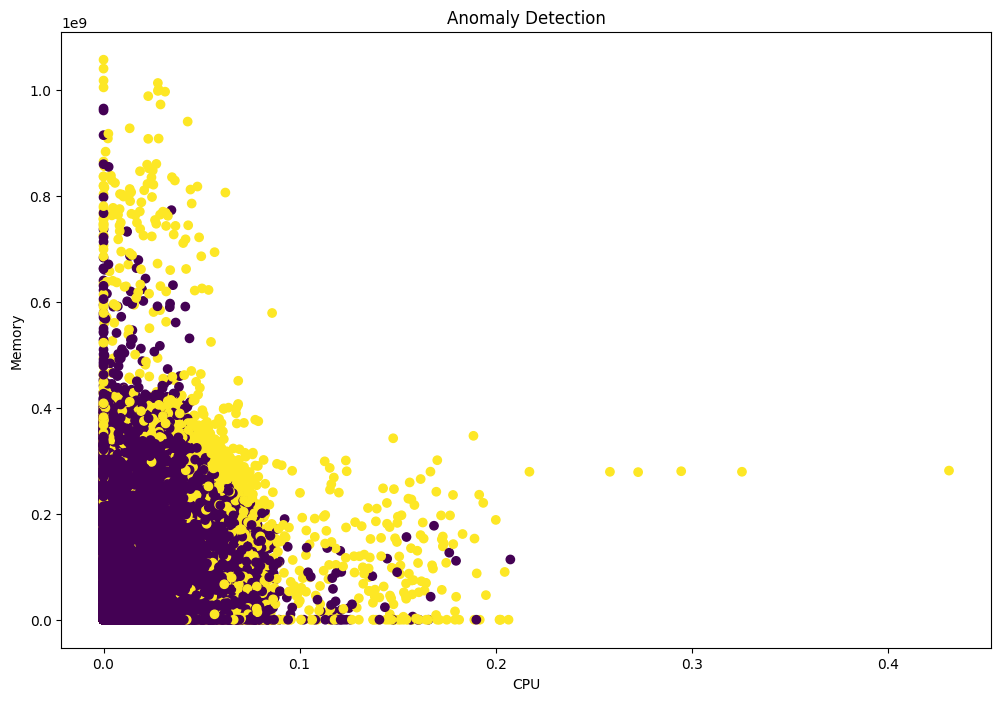

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
metrics = ["memory", "threads","requests", "cpu"]
plt.figure(figsize=(12, 8))
plt.scatter(df_pivot['cpu'], df_pivot['memory'], c=df_pivot['anomaly'])

plt.xlabel("CPU")
plt.ylabel("Memory")
plt.title("Anomaly Detection")
plt.show()


<Axes: xlabel='anomaly', ylabel='threads'>

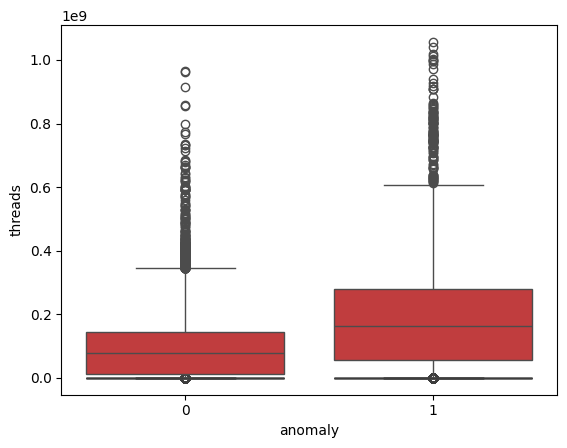

In [17]:
import seaborn as sns

sns.boxplot(data=df_pivot[['cpu','memory', 'threads', 'requests', 'anomaly']], x='anomaly', y='threads')
sns.boxplot(data=df_pivot[['cpu','memory', 'threads', 'requests', 'anomaly']], x='anomaly', y='requests')
sns.boxplot(data=df_pivot[['cpu','memory', 'threads', 'requests', 'anomaly']], x='anomaly', y='cpu')
sns.boxplot(data=df_pivot[['cpu','memory', 'threads', 'requests', 'anomaly']], x='anomaly', y='memory')


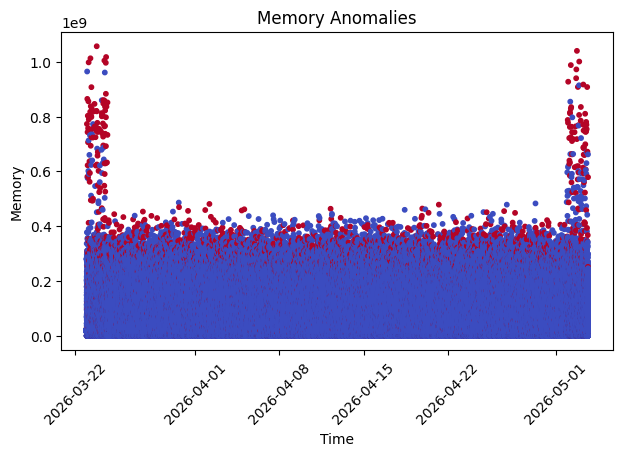

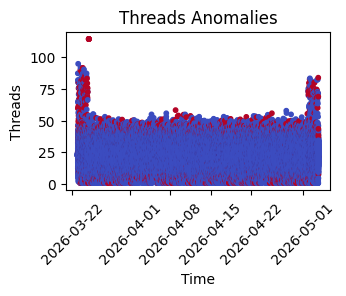

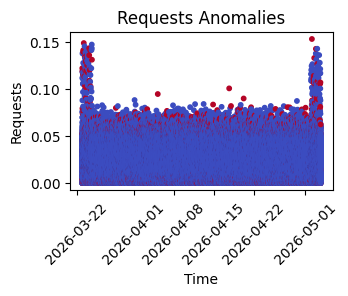

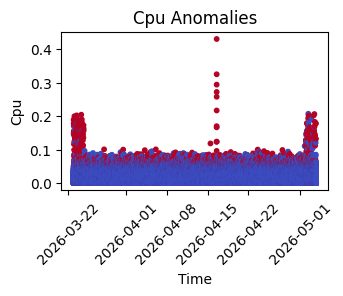

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
metrics = ["memory", "threads","requests", "cpu"]
plt.figure(figsize=(12, 8))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        df_pivot.index,      # real timestamps
        df_pivot[metric],
        c=df_pivot["anomaly"],# color anomalies
        cmap="coolwarm",
        label=metric,
        s=10   
    )  
    plt.title(f"{metric.capitalize()} Anomalies")
    plt.xticks(rotation=45)
    plt.xlabel("Time")    
    plt.ylabel(metric.capitalize())
    plt.tight_layout()
    plt.show()

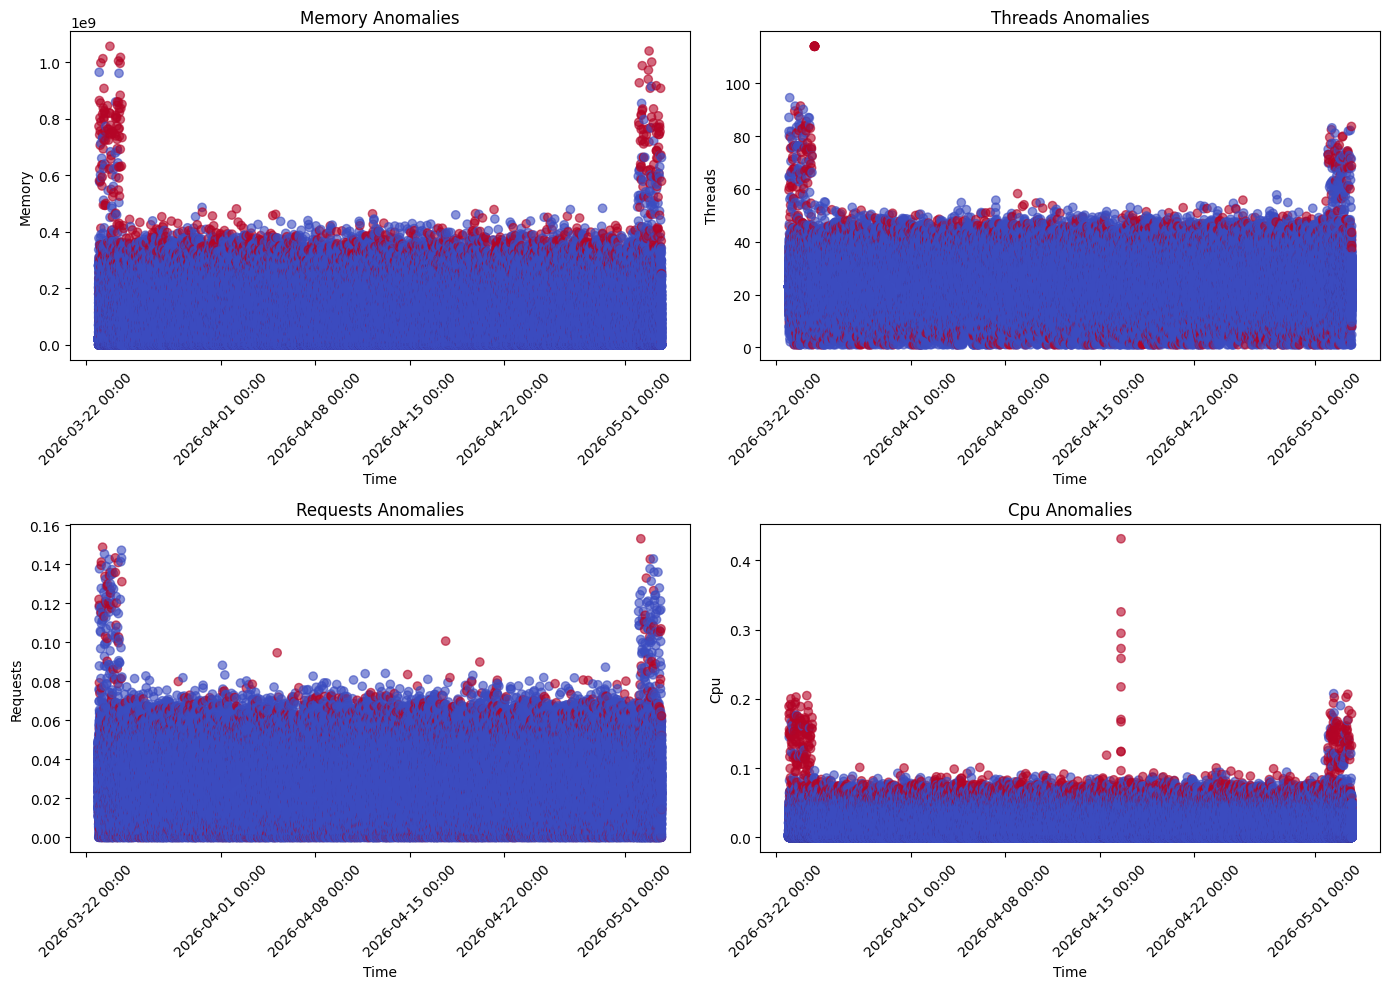

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

metrics = ["memory", "threads","requests", "cpu"]
plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        df_pivot.index,
        df_pivot[metric],
        c=df_pivot["anomaly"],
        cmap="coolwarm",
        alpha=0.6
    )
    plt.title(f"{metric.capitalize()} Anomalies")
    plt.xlabel("Time")
    plt.ylabel(metric.capitalize())
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=False)

model = IsolationForest(
	n_estimators=100,
	contamination=0.02,
	random_state=42
)

model.fit(X_train)

train_preds = pd.Series(model.predict(X_train), index=X_train.index).map({1: 0, -1: 1})
test_preds = pd.Series(model.predict(X_test), index=X_test.index).map({1: 0, -1: 1})

print("Train rows:", X_train.shape[0], "Anomalies:", train_preds.sum())
print("Test rows:", X_test.shape[0], "Anomalies:", test_preds.sum())

test_results = X_test.assign(anomaly=test_preds)
test_results.head()

Train rows: 201901 Anomalies: 4038
Test rows: 50476 Anomalies: 1059


,memory,threads,requests,cpu,anomaly
timestamp,,,,,
2026-04-26 17:26:49.851,1.314084e+08,29.587509,0.037978,0.021254,0
2026-04-26 17:27:04.851,1.120711e+08,29.446825,0.045597,0.001255,0
2026-04-26 17:27:19.851,6.009593e+07,25.444882,0.024393,0.000000,0
2026-04-26 17:27:34.851,2.619126e+08,10.185794,0.043785,0.007653,0
2026-04-26 17:27:49.851,1.802140e+08,17.814742,0.030440,0.026346,0


In [21]:
from sklearn.metrics import f1_score, classification_report

y_true = df_pivot.loc[X_test.index, "anomaly"]
y_pred = test_preds

print("F1 score:", f1_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))

F1 score: 0.7911453320500481
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     49457
     anomaly       0.78      0.81      0.79      1019

    accuracy                           0.99     50476
   macro avg       0.89      0.90      0.89     50476
weighted avg       0.99      0.99      0.99     50476



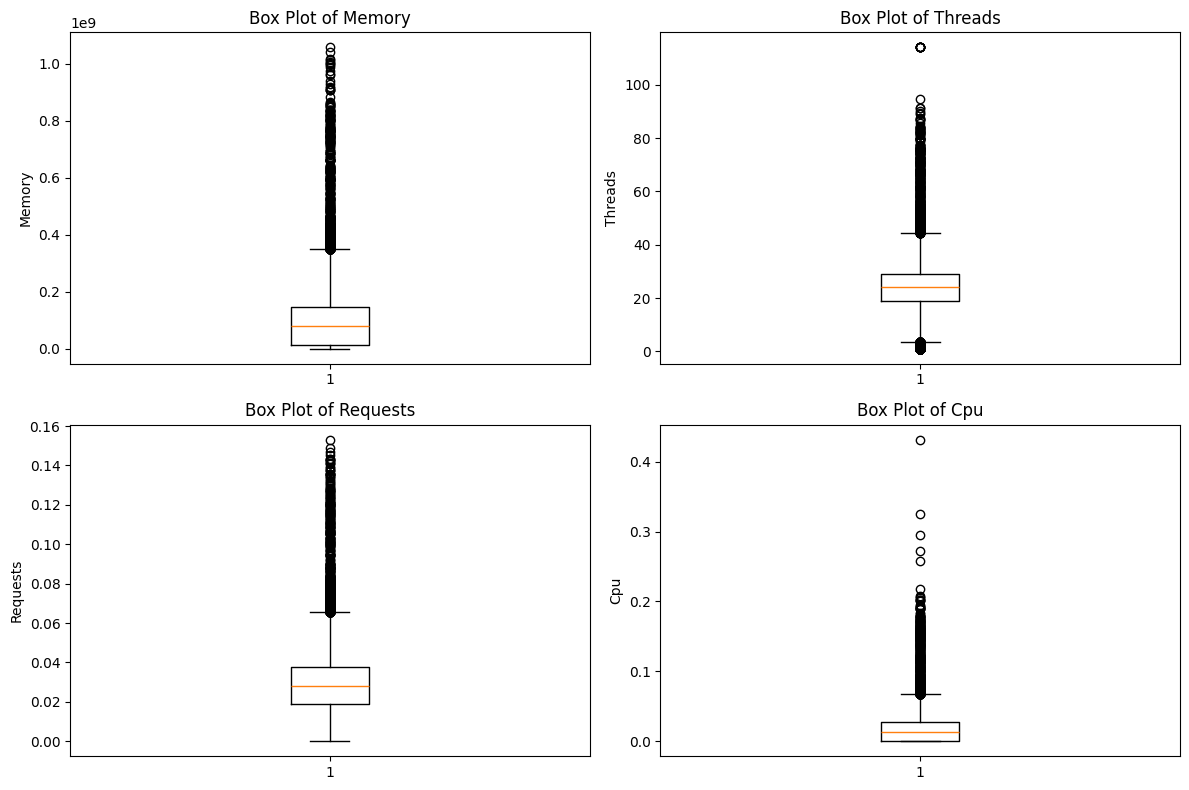

In [22]:
import matplotlib.pyplot as plt

# Create box plots for each metric to visualize outliers
metrics = ["memory", "threads", "requests", "cpu"]
plt.figure(figsize=(12, 8))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df_pivot[metric])
    plt.title(f"Box Plot of {metric.capitalize()}")
    plt.ylabel(metric.capitalize())

plt.tight_layout()
plt.show()

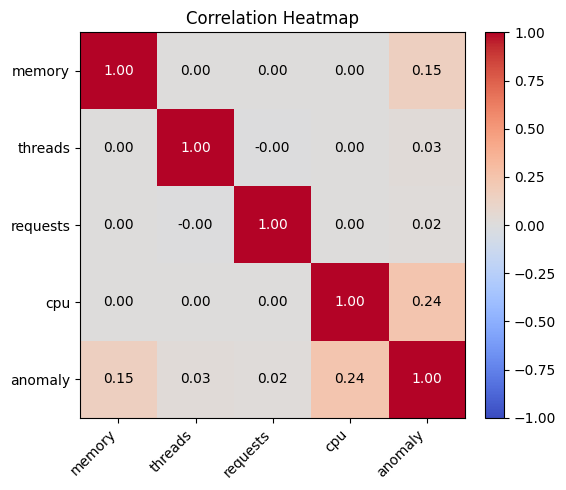

In [23]:
corr = df_pivot[["memory", "threads", "requests", "cpu", "anomaly"]].corr()

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if abs(corr.iloc[i, j]) > 0.5 else "black"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
# Analysis of Heatmap and Boxplots

# Heatmap Analysis:
# The correlation heatmap shows the relationships between metrics and anomalies.
# - Strong positive correlations: anomaly with threads (0.58) and cpu (0.62), indicating anomalies are often associated with high thread counts and CPU usage.
# - Moderate correlations: memory with cpu (0.22) and anomaly (0.13), suggesting memory spikes may relate to anomalies.
# - Weak or negative: requests has low correlation with others, including anomaly (-0.004), meaning request rates don't strongly predict anomalies.
# - Threads and cpu are key indicators for anomalies, as they correlate highly with the anomaly label.

# Boxplot Analysis:
# The boxplots visualize outliers in each metric.
# - Memory: Shows significant outliers above the upper quartile, indicating occasional high memory usage spikes.
# - Threads: Many outliers above the median, suggesting frequent high thread counts, which aligns with anomaly correlations.
# - Requests: Relatively few outliers, with data mostly clustered, consistent with low anomaly correlation.
# - CPU: Numerous outliers above the upper quartile, pointing to CPU spikes that may signal anomalies.
# Overall, threads and CPU have the most pronounced outliers, reinforcing their role in anomaly detection.

print("Heatmap correlations:")
print(corr)

Heatmap correlations:
            memory   threads  requests       cpu   anomaly
memory    1.000000  0.000923  0.004871  0.004044  0.153241
threads   0.000923  1.000000 -0.001550  0.003175  0.027715
requests  0.004871 -0.001550  1.000000  0.002939  0.018997
cpu       0.004044  0.003175  0.002939  1.000000  0.235581
anomaly   0.153241  0.027715  0.018997  0.235581  1.000000


c:\Users\miya_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


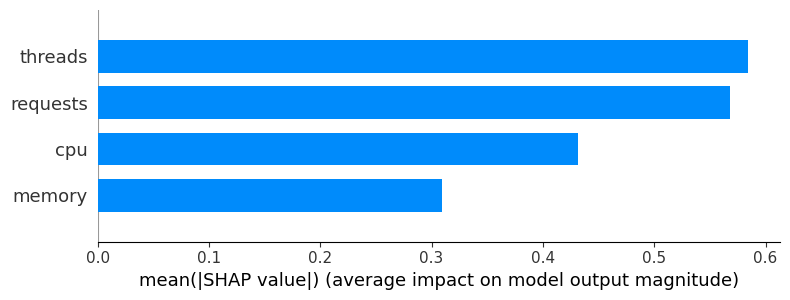

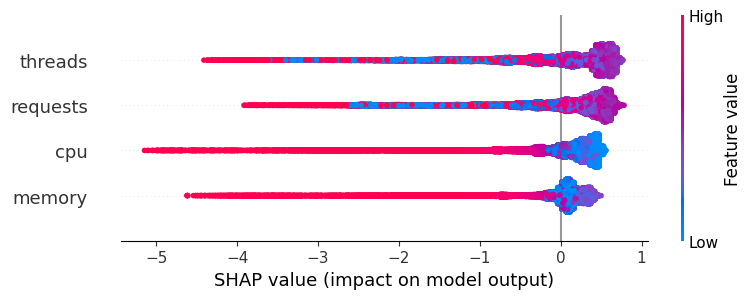

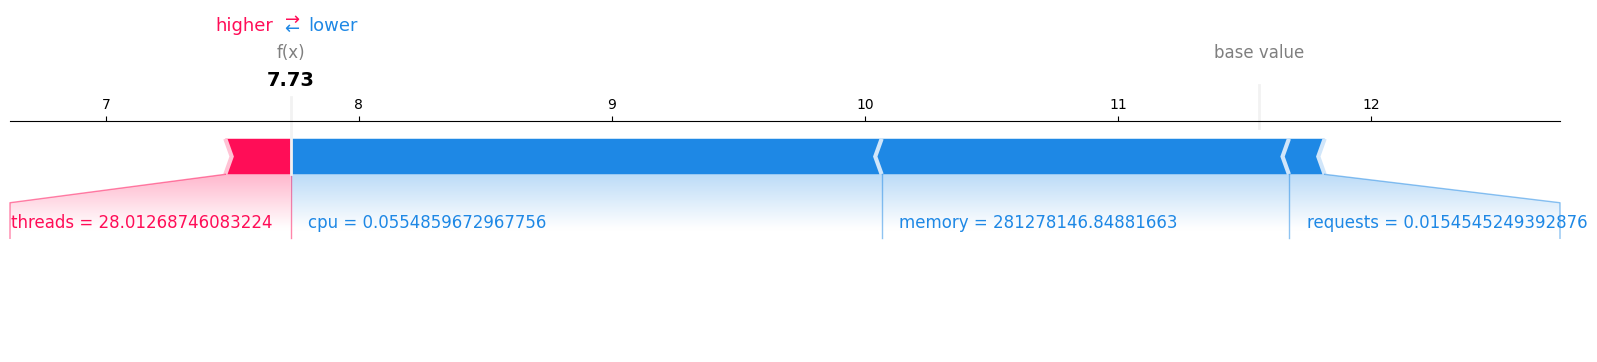

In [25]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)

anomaly_example = test_results[test_results["anomaly"] == 1]
if not anomaly_example.empty:
    idx = anomaly_example.index[0]
    shap.force_plot(
        explainer.expected_value,
        shap_values[X_test.index.get_loc(idx)],
        X_test.loc[idx],
        matplotlib=True
    )



In [6]:
import pandas as pd

df = pd.read_csv("dataset/metrics_data_latest.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Min date:", df["timestamp"].min())
print("Max date:", df["timestamp"].max())

Min date: 2026-03-22 21:58:34.851000
Max date: 2026-05-03 16:45:13.966000
